# Text Classification

1) Setup path  
2) (Proof) Load dataset via `datasets.load_dataset`  
3) Load via `modules.data_loader.load_data` (single source of truth for pipeline)  
4) TF‑IDF (subset) → Save features  
5) Train/Eval Logistic Regression baseline → Pretty output  


In [35]:
# 0) Quick environment check (optional but useful when debugging)
from pathlib import Path
import os
import sys

CWD = Path.cwd()

# if notebook is inside notebooks/
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

print("Current working directory:", CWD)
print("Project root:", PROJECT_ROOT)
print("Project files:", os.listdir(PROJECT_ROOT))

Current working directory: c:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\notebooks
Project root: c:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule
Project files: ['.git', '.gitignore', 'config.py', 'data', 'features', 'LICENSE', 'models', 'modules', 'notebooks', 'README.md', 'report', 'requirements.txt', 'venv', '__pycache__']


In [36]:
# 1) One-time setup: add project root to sys.path so imports from ../modules work
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


PROJECT_ROOT: c:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule


## 2) Dependencies (install only if missing)



In [37]:
import importlib

# module_name : pip_package_name
REQUIRED_PACKAGES = {
    "datasets": "datasets",
    "sklearn": "scikit-learn",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}

missing = []

for module_name, pip_name in REQUIRED_PACKAGES.items():
    try:
        importlib.import_module(module_name)
        print(f"✓ {module_name} already installed")
    except ImportError:
        missing.append(pip_name)

if missing:
    import subprocess, sys
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
    print("Installation finished.")
else:
    print("All required packages already installed.")

✓ datasets already installed
✓ sklearn already installed
✓ numpy already installed
✓ pandas already installed
✓ matplotlib already installed
All required packages already installed.


## 3) Proof: load dataset directly from Hugging Face



In [38]:
from datasets import load_dataset

ds = load_dataset("ag_news")
print(ds)
print(ds["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


## 4) Pipeline load (via module)



In [39]:
from modules.data_loader import load_data

train_texts, train_labels, test_texts, test_labels, info = load_data("ag_news")
print(info)
print("Train:", len(train_texts), "Test:", len(test_texts))
print("Sample text:", train_texts[0][:120] + ("..." if len(train_texts[0]) > 120 else ""))
print("Sample label:", train_labels[0])


DatasetInfo(name='ag_news', train_size=120000, test_size=7600, text_field='text', label_field='label', num_classes=4)
Train: 120000 Test: 7600
Sample text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,...
Sample label: 2


## 5) PREPROCESS 

In [40]:
from modules.text_preprocess import *

# Bo sung sau


## 6) FEATURE EXTRACTION

# REMOVE CACHE

In [86]:
import importlib
import config 
import modules.pipeline
importlib.reload(config)
importlib.reload(modules.pipeline)

<module 'modules.pipeline' from 'c:\\Users\\ghuy2\\Documents\\BACH KHOA\\HK_252\\ML\\MachineLearning_TextModule\\modules\\pipeline.py'>

In [77]:
from config import Config
from modules.pipeline import build_features

cfg = Config()
X_train, X_test, N_TRAIN, N_TEST = build_features(
    cfg,
    train_texts,
    test_texts
)

print(X_train.shape, X_test.shape)

SBERT embeddings saved:
C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\features\bert\bert_train.npy C:\Users\ghuy2\Documents\BACH KHOA\HK_252\ML\MachineLearning_TextModule\features\bert\bert_test.npy
(2000, 384) (500, 384)


## 7) Train/Evaluation 

,accuracy,f1_weighted,method
0,0.85,0.848682,Model


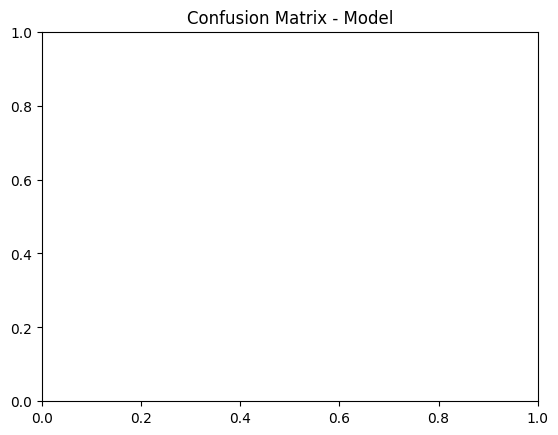

(EvalResult(accuracy=0.85, f1_weighted=0.8486816189866297),
    accuracy  f1_weighted method
 0      0.85     0.848682  Model)

In [87]:
from modules.pipeline import run_evaluation

run_evaluation(X_train, train_labels, X_test, test_labels)